# Kshitij — Regression Baselines: `vcm_output.parquet`

**Project:** Space debris trajectory prediction  
**Role:** Person B — Regression Baselines

---

## How this notebook is structured (read before running)

Each section is **independently runnable** after the setup section. If Colab disconnects:
- Re-run **Section 0** (setup + Drive mount) — always needed
- Re-run **Section 1** (load + feature engineering) — always needed
- Then jump directly to whichever section you were on

Each section saves its outputs to Google Drive so nothing is lost on disconnect.

| Section | What it does | Runtime estimate |
|---|---|---|
| 0 | Setup, Drive mount | ~1 min |
| 1 | Load data, engineer features, build targets, split | ~2 min |
| 2 | Naive baselines (persist, median) | ~1 min |
| 3 | Ridge + Random Forest | ~5 min |
| 4 | XGBoost | ~5 min |
| 5 | Metrics report + plots | ~3 min |


---
## Section 0 — Setup
**Run this first every time, even after a disconnect.**

In [1]:
# Install dependencies
!pip install pyarrow xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

print('All imports OK')
print('XGBoost version:', xgb.__version__)

All imports OK
XGBoost version: 3.2.0


In [2]:
# Mount Google Drive — saves outputs so disconnects don't lose work
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/space_debris_baselines'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Outputs will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Outputs will be saved to: /content/drive/MyDrive/space_debris_baselines


In [3]:
# Upload vcm_output.parquet here
# Either:
#   (a) drag the file into the Colab file panel on the left, or
#   (b) put it in your Drive and set PARQUET_PATH to that path

PARQUET_PATH = '/content/drive/MyDrive/vcm_output.parquet'  # change if in Drive, e.g. '/content/drive/MyDrive/vcm_output.parquet'

# Verify
assert os.path.exists(PARQUET_PATH), f'File not found: {PARQUET_PATH}'
print(f'Found file: {os.path.getsize(PARQUET_PATH) / 1e6:.1f} MB')

Found file: 39.9 MB


---
## Section 1 — Load, Feature Engineering, Target Construction, Split
**Run after Section 0. Must complete before any other section.**

### What this data is
This is VCM (Vector Covariance Message) output — real space object tracking data. Each row is one observation of one object at one epoch. Key column groups:
- **Identity:** `satellite_number`, `int_des`, `epoch_time_utc`
- **State vectors:** `j2k_pos_x/y/z`, `j2k_vel_x/y/z` (ECI/J2K frame) and equivalents in ECI and EFG
- **Uncertainty (UVW sigmas):** `vector_u/v/w_sigma_km` — these ARE our regression targets
- **Physics config:** `ballistic_coef_m2kg`, `solar_rad_press_coeff_m2kg`, `bdot_m2kg_s`
- **Space weather:** `solar_flux_f10`, `average_f10`, `average_ap`

### Target strategy
We predict **future uncertainty growth** — for each object, given its state at time T, can we predict its UVW sigmas at T+1 observation?
This is leakage-safe because inputs are state at T, targets are uncertainty at T+1.

In [4]:
print('Loading parquet...')
df = pd.read_parquet(PARQUET_PATH)
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):',  df.columns.tolist())
print()
print(df.dtypes)
print()

print(df.head())
print(df.columns)

Loading parquet...
Shape: (196722, 63)
Columns (63): ['message_type', 'message_time_utc', 'center', 'satellite_number', 'int_des', 'common_name', 'epoch_time_utc', 'epoch_rev', 'j2k_pos_x', 'j2k_pos_y', 'j2k_pos_z', 'j2k_vel_x', 'j2k_vel_y', 'j2k_vel_z', 'eci_pos_x', 'eci_pos_y', 'eci_pos_z', 'eci_vel_x', 'eci_vel_y', 'eci_vel_z', 'efg_pos_x', 'efg_pos_y', 'efg_pos_z', 'efg_vel_x', 'efg_vel_y', 'efg_vel_z', 'geopotential', 'drag_model', 'lunar_solar', 'solar_rad_press', 'solid_earth_tides', 'in_track_thrust', 'ballistic_coef_m2kg', 'bdot_m2kg_s', 'solar_rad_press_coeff_m2kg', 'edr_wkg', 'thrust_accel_ms2', 'cm_offset_m', 'solar_flux_f10', 'average_f10', 'average_ap', 'tai_utc_s', 'ut1_utc_s', 'ut1_rate_ms_day', 'polar_mot_x_arcsec', 'polar_mot_y_arcsec', 'iau_1980_nutat', 'time_const_leap_second_time_utc', 'integrator_mode', 'coord_sys', 'partials', 'step_mode', 'fixed_step', 'step_size_selection', 'initial_step_size_s', 'error_control', 'vector_u_sigma_km', 'vector_v_sigma_km', 'vecto

In [6]:
print('Loading parquet...')
df = pd.read_parquet(PARQUET_PATH)
print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):',  df.columns.tolist())
print()
print(df.dtypes)
print()
print('Sample:')
df.head(3)

Loading parquet...
Shape: (196722, 63)
Columns (63): ['message_type', 'message_time_utc', 'center', 'satellite_number', 'int_des', 'common_name', 'epoch_time_utc', 'epoch_rev', 'j2k_pos_x', 'j2k_pos_y', 'j2k_pos_z', 'j2k_vel_x', 'j2k_vel_y', 'j2k_vel_z', 'eci_pos_x', 'eci_pos_y', 'eci_pos_z', 'eci_vel_x', 'eci_vel_y', 'eci_vel_z', 'efg_pos_x', 'efg_pos_y', 'efg_pos_z', 'efg_vel_x', 'efg_vel_y', 'efg_vel_z', 'geopotential', 'drag_model', 'lunar_solar', 'solar_rad_press', 'solid_earth_tides', 'in_track_thrust', 'ballistic_coef_m2kg', 'bdot_m2kg_s', 'solar_rad_press_coeff_m2kg', 'edr_wkg', 'thrust_accel_ms2', 'cm_offset_m', 'solar_flux_f10', 'average_f10', 'average_ap', 'tai_utc_s', 'ut1_utc_s', 'ut1_rate_ms_day', 'polar_mot_x_arcsec', 'polar_mot_y_arcsec', 'iau_1980_nutat', 'time_const_leap_second_time_utc', 'integrator_mode', 'coord_sys', 'partials', 'step_mode', 'fixed_step', 'step_size_selection', 'initial_step_size_s', 'error_control', 'vector_u_sigma_km', 'vector_v_sigma_km', 'vecto

,message_type,message_time_utc,center,satellite_number,int_des,common_name,epoch_time_utc,epoch_rev,j2k_pos_x,j2k_pos_y,...,step_size_selection,initial_step_size_s,error_control,vector_u_sigma_km,vector_v_sigma_km,vector_w_sigma_km,vector_ud_sigma_kms,vector_vd_sigma_kms,vector_wd_sigma_kms,source_file
0,SP VECTOR/COVARIANCE MESSAGE - V2.0,2022 244 (01 SEP) 03:13:33.000,,5,1958-002B,,2022 244 (01 SEP) 01:38:58.810,29275,2263.958986,-6411.485926,...,MANUAL,20.0,1.000000e-14,0.0089,0.0496,0.0062,0.0001,0.0,0.0,00005.vcm
1,SP VECTOR/COVARIANCE MESSAGE - V2.0,2022 244 (01 SEP) 05:43:28.000,,5,1958-002B,,2022 244 (01 SEP) 03:58:19.185,29276,4509.520581,-4610.094984,...,MANUAL,20.0,1.000000e-14,0.0087,0.0470,0.0079,0.0000,0.0,0.0,00005.vcm
2,SP VECTOR/COVARIANCE MESSAGE - V2.0,2022 244 (01 SEP) 07:17:21.000,,5,1958-002B,,2022 244 (01 SEP) 06:18:31.501,29277,6156.330978,-1669.959905,...,MANUAL,20.0,1.000000e-14,0.0089,0.0450,0.0123,0.0000,0.0,0.0,00005.vcm


In [7]:
# Quick data quality check
print('=== Null counts (non-zero only) ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls[nulls > 0].shape[0] > 0 else 'No nulls!')

print()
print('=== Numeric summary ===')
print(df.describe())

=== Null counts (non-zero only) ===
No nulls!

=== Numeric summary ===
       satellite_number      epoch_rev      j2k_pos_x      j2k_pos_y  \
count     196722.000000  196722.000000  196722.000000  196722.000000   
mean         445.247756   39415.599323     241.434795     200.871217   
std          275.779529   35590.404973    4424.838005    4461.722397   
min            5.000000       1.000000  -83991.099767 -107749.804339   
25%          202.000000   11771.250000   -2864.144414   -2926.928746   
50%          409.000000   18355.000000     359.475270     320.398458   
75%          700.000000   84315.750000    3195.104200    3182.373396   
max          979.000000   99998.000000  150419.466138  117977.260881   

           j2k_pos_z      j2k_vel_x      j2k_vel_y      j2k_vel_z  \
count  196722.000000  196722.000000  196722.000000  196722.000000   
mean     4399.793688      -0.246818      -0.079309       0.132901   
std      2373.222007       4.160169       4.129784       4.432113   
min 

In [14]:
import pandas as pd

# Parse epoch time and sort chronologically
# This is critical — temporal ordering prevents data leakage in the split
df['epoch_dt'] = pd.to_datetime(df['epoch_time_utc'], format='%Y %j (%d %b) %H:%M:%S.%f', errors='coerce')
df = df.sort_values(['satellite_number', 'epoch_dt']).reset_index(drop=True)

print('Date range:')
print('  Start:', df['epoch_dt'].min())
print('  End:  ', df['epoch_dt'].max())
print()
print('Unique objects (satellite_number):', df['satellite_number'].nunique())
print('Rows per object (mean):', df.groupby('satellite_number').size().mean().round(1))

Date range:
  Start: 2022-09-01 00:01:13.879000
  End:   2023-03-01 19:01:11.172000

Unique objects (satellite_number): 267
Rows per object (mean): 736.8


In [15]:
# === Derived features from raw state vectors ===

# Altitude from J2K position (Earth radius ~ 6371 km)
EARTH_RADIUS_KM = 6371.0
df['altitude_km'] = np.sqrt(df['j2k_pos_x']**2 + df['j2k_pos_y']**2 + df['j2k_pos_z']**2) - EARTH_RADIUS_KM

# Speed magnitude
df['speed_kms'] = np.sqrt(df['j2k_vel_x']**2 + df['j2k_vel_y']**2 + df['j2k_vel_z']**2)

# Total position uncertainty (UVW combined in quadrature)
df['sigma_pos_total_km'] = np.sqrt(
    df['vector_u_sigma_km']**2 +
    df['vector_v_sigma_km']**2 +
    df['vector_w_sigma_km']**2
)

# Uncertainty volume proxy (log scale — this is what Mir calls log_uncertainty_volume)
df['log_sigma_pos_total'] = np.log1p(df['sigma_pos_total_km'])

# Altitude bands (for stratified evaluation)
df['altitude_band'] = pd.cut(
    df['altitude_km'],
    bins=[0, 400, 800, 1200, 2000, np.inf],
    labels=['VLEO', 'LEO_low', 'LEO_mid', 'LEO_high', 'MEO+']
)

print('Derived features added:')
print(df[['altitude_km', 'speed_kms', 'sigma_pos_total_km', 'log_sigma_pos_total', 'altitude_band']].describe())

Derived features added:
         altitude_km      speed_kms  sigma_pos_total_km  log_sigma_pos_total
count  196722.000000  196722.000000       196722.000000        196722.000000
mean     1189.741770       7.344035            0.605539             0.041889
std      2722.160452       0.394326          249.073676             0.048036
min       293.174757       1.159606            0.004877             0.004866
25%       798.746222       7.330935            0.023991             0.023708
50%       917.015637       7.400918            0.032615             0.032094
75%      1051.522300       7.472245            0.048583             0.047440
max    159963.646540       9.526052       110472.561292            11.612532


In [16]:
# === Build future targets (shift within each object's time series) ===
# For each object, target = uncertainty at the NEXT observation
# This is the leakage-safe formulation: inputs at T, targets at T+1

grp = df.groupby('satellite_number')

df['target_sigma_u'] = grp['vector_u_sigma_km'].shift(-1)
df['target_sigma_v'] = grp['vector_v_sigma_km'].shift(-1)
df['target_sigma_w'] = grp['vector_w_sigma_km'].shift(-1)
df['target_sigma_total'] = grp['sigma_pos_total_km'].shift(-1)
df['target_log_sigma'] = grp['log_sigma_pos_total'].shift(-1)

# Time gap to next observation (in hours) — important feature
df['time_gap_to_next_hr'] = (
    grp['epoch_dt'].shift(-1) - df['epoch_dt']
).dt.total_seconds() / 3600

# Drop the last row per object (no next observation)
df_model = df.dropna(subset=['target_sigma_total', 'time_gap_to_next_hr']).copy()
# Also drop rows where gap > 30 days (likely gaps between data batches, not real predictions)
df_model = df_model[df_model['time_gap_to_next_hr'] <= 24 * 30]

print(f'Rows after dropping last-per-object and large gaps: {len(df_model):,}')
print()
print('Target distributions:')
print(df_model[['target_sigma_u', 'target_sigma_v', 'target_sigma_w', 'target_sigma_total', 'target_log_sigma']].describe())

Rows after dropping last-per-object and large gaps: 163,588

Target distributions:
       target_sigma_u  target_sigma_v  target_sigma_w  target_sigma_total  \
count   163588.000000   163588.000000   163588.000000       163588.000000   
mean         0.401512        0.429262        0.401947            0.719201   
std        157.695057      157.694963      157.695025          273.135759   
min          0.001500        0.003000        0.002100            0.004877   
25%          0.005700        0.021400        0.006800            0.023986   
50%          0.008100        0.029550        0.009300            0.032651   
75%          0.012300        0.044300        0.013800            0.048617   
max      63781.363000    63781.363000    63781.363000       110472.561292   

       target_log_sigma  
count     163588.000000  
mean           0.041893  
std            0.048977  
min            0.004866  
25%            0.023702  
50%            0.032129  
75%            0.047472  
max           1

In [17]:
# === Define input feature sets ===
# Only variables available at prediction time T (no future leakage)

FEATURE_COLS = [
    # --- Orbital state (J2K ECI) ---
    'j2k_pos_x', 'j2k_pos_y', 'j2k_pos_z',
    'j2k_vel_x', 'j2k_vel_y', 'j2k_vel_z',
    # --- Derived orbital quantities ---
    'altitude_km', 'speed_kms',
    # --- Current uncertainty (input, not target) ---
    'vector_u_sigma_km', 'vector_v_sigma_km', 'vector_w_sigma_km',
    'sigma_pos_total_km', 'log_sigma_pos_total',
    # --- Physics / object properties ---
    'ballistic_coef_m2kg', 'bdot_m2kg_s', 'solar_rad_press_coeff_m2kg',
    'edr_wkg', 'thrust_accel_ms2', 'cm_offset_m',
    # --- Space weather ---
    'solar_flux_f10', 'average_f10', 'average_ap',
    # --- Timing ---
    'time_gap_to_next_hr', 'epoch_rev',
    # --- Earth orientation (subtle but real effects) ---
    'ut1_utc_s', 'polar_mot_x_arcsec', 'polar_mot_y_arcsec',
    'initial_step_size_s', 'error_control',
]

# Primary target for most baselines
PRIMARY_TARGET = 'target_log_sigma'     # log(1 + sigma_total_next)
ALL_TARGETS = ['target_sigma_u', 'target_sigma_v', 'target_sigma_w', 'target_log_sigma']

# Drop features with too many nulls
null_frac = df_model[FEATURE_COLS].isnull().mean()
drop_cols = null_frac[null_frac > 0.5].index.tolist()
if drop_cols:
    print(f'Dropping features with >50% nulls: {drop_cols}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in drop_cols]

# Fill remaining nulls with column median (only for features, not targets)
df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median())

print(f'Final feature count: {len(FEATURE_COLS)}')
print('Features:', FEATURE_COLS)

Final feature count: 29
Features: ['j2k_pos_x', 'j2k_pos_y', 'j2k_pos_z', 'j2k_vel_x', 'j2k_vel_y', 'j2k_vel_z', 'altitude_km', 'speed_kms', 'vector_u_sigma_km', 'vector_v_sigma_km', 'vector_w_sigma_km', 'sigma_pos_total_km', 'log_sigma_pos_total', 'ballistic_coef_m2kg', 'bdot_m2kg_s', 'solar_rad_press_coeff_m2kg', 'edr_wkg', 'thrust_accel_ms2', 'cm_offset_m', 'solar_flux_f10', 'average_f10', 'average_ap', 'time_gap_to_next_hr', 'epoch_rev', 'ut1_utc_s', 'polar_mot_x_arcsec', 'polar_mot_y_arcsec', 'initial_step_size_s', 'error_control']


In [18]:
# === Temporal train/val/test split ===
# CRITICAL: sort by time globally, then slice. Never shuffle.
# 70% train / 15% val / 15% test

df_model = df_model.sort_values('epoch_dt').reset_index(drop=True)
n = len(df_model)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_df = df_model.iloc[:train_end].copy()
val_df   = df_model.iloc[train_end:val_end].copy()
test_df  = df_model.iloc[val_end:].copy()

print(f'Train: {len(train_df):>7,} rows  ({train_df["epoch_dt"].min().date()} → {train_df["epoch_dt"].max().date()})')
print(f'Val:   {len(val_df):>7,} rows  ({val_df["epoch_dt"].min().date()} → {val_df["epoch_dt"].max().date()})')
print(f'Test:  {len(test_df):>7,} rows  ({test_df["epoch_dt"].min().date()} → {test_df["epoch_dt"].max().date()})')

# Verify no time leakage
assert train_df['epoch_dt'].max() <= val_df['epoch_dt'].min(), 'LEAKAGE: train overlaps val!'
assert val_df['epoch_dt'].max() <= test_df['epoch_dt'].min(), 'LEAKAGE: val overlaps test!'
print('\nSplit verified: no temporal leakage.')

Train: 114,511 rows  (2022-09-01 → 2023-01-05)
Val:    24,538 rows  (2023-01-05 → 2023-02-03)
Test:   24,539 rows  (2023-02-03 → 2023-03-01)

Split verified: no temporal leakage.


In [19]:
# Extract arrays and scale
X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values

y_train = train_df[PRIMARY_TARGET].values
y_val   = val_df[PRIMARY_TARGET].values
y_test  = test_df[PRIMARY_TARGET].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train!
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'X_train: {X_train.shape}, y_train mean: {y_train.mean():.4f}, std: {y_train.std():.4f}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (114511, 29), y_train mean: 0.0398, std: 0.0487
X_val:   (24538, 29)
X_test:  (24539, 29)


In [20]:
# Save processed data so later sections don't need to reload from scratch
save_path = os.path.join(SAVE_DIR, 'processed_splits.pkl')
with open(save_path, 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'X_train_sc': X_train_sc, 'X_val_sc': X_val_sc, 'X_test_sc': X_test_sc,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test,
        'train_df': train_df, 'val_df': val_df, 'test_df': test_df,
        'FEATURE_COLS': FEATURE_COLS,
        'PRIMARY_TARGET': PRIMARY_TARGET,
        'scaler': scaler,
    }, f)
print(f'Saved processed splits to: {save_path}')

Saved processed splits to: /content/drive/MyDrive/space_debris_baselines/processed_splits.pkl


---
## Section 2 — Naive Baselines
**Prerequisite: Section 0 + Section 1 completed (or load from Drive below)**

These are your floor. If ML can't beat these, something is wrong with features or targets.

In [ ]:
# Run this cell to reload if you reconnected after a disconnect
import pickle, os
SAVE_DIR = '/content/drive/MyDrive/space_debris_baselines'

with open(os.path.join(SAVE_DIR, 'processed_splits.pkl'), 'rb') as f:
    d = pickle.load(f)

X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
X_train_sc, X_val_sc, X_test_sc = d['X_train_sc'], d['X_val_sc'], d['X_test_sc']
y_train, y_val, y_test = d['y_train'], d['y_val'], d['y_test']
train_df, val_df, test_df = d['train_df'], d['val_df'], d['test_df']
FEATURE_COLS = d['FEATURE_COLS']
PRIMARY_TARGET = d['PRIMARY_TARGET']
scaler = d['scaler']
print('Reloaded splits from Drive.')

In [21]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}  # will accumulate all model results

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'y_pred': y_pred}
    print(f'{name:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return mae, rmse, r2

In [24]:
print('=== NAIVE BASELINES (evaluated on test set) ===\n')

# 1. Persist: predict current sigma as the future sigma
#    i.e. assume nothing changes — simplest possible baseline
log_sigma_col_idx = FEATURE_COLS.index('log_sigma_pos_total')
y_pred_persist = X_test[:, log_sigma_col_idx]
evaluate('Persist (current sigma)', y_test, y_pred_persist)

# 2. Global train-set mean
y_pred_mean = np.full_like(y_test, y_train.mean())
evaluate('Global mean', y_test, y_pred_mean)

# 3. Altitude-band median (compute from train only, apply to test)
alt_band_col = 'altitude_band'
alt_medians = train_df.groupby(alt_band_col)[PRIMARY_TARGET].median()
y_pred_alt = test_df[alt_band_col].map(alt_medians).astype(float).fillna(np.median(y_train)).values
evaluate('Altitude-band median', y_test, y_pred_alt)

# 4. Per-object median (from train history)
obj_medians = train_df.groupby('satellite_number')[PRIMARY_TARGET].median()
y_pred_obj = test_df['satellite_number'].map(obj_medians).fillna(np.median(y_train)).values
evaluate('Per-object median', y_test, y_pred_obj)

print()
print('The persist baseline is the most important floor — ML must beat it.')

=== NAIVE BASELINES (evaluated on test set) ===

Persist (current sigma)              MAE=0.0117  RMSE=0.0309  R²=0.6513
Global mean                          MAE=0.0213  RMSE=0.0530  R²=-0.0289
Altitude-band median                 MAE=0.0220  RMSE=0.0540  R²=-0.0655
Per-object median                    MAE=0.0162  RMSE=0.0393  R²=0.4355

The persist baseline is the most important floor — ML must beat it.


In [25]:
# Save naive results
with open(os.path.join(SAVE_DIR, 'results.pkl'), 'wb') as f:
    pickle.dump(results, f)
print('Naive baseline results saved.')

Naive baseline results saved.


---
## Section 3 — Ridge Regression + Random Forest
**Prerequisite: Section 0 + Section 1. Reload cell at top of this section if reconnected.**

In [ ]:
# Reload after disconnect
import pickle, os, numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
SAVE_DIR = '/content/drive/MyDrive/space_debris_baselines'

with open(os.path.join(SAVE_DIR, 'processed_splits.pkl'), 'rb') as f:
    d = pickle.load(f)
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
X_train_sc, X_val_sc, X_test_sc = d['X_train_sc'], d['X_val_sc'], d['X_test_sc']
y_train, y_val, y_test = d['y_train'], d['y_val'], d['y_test']
train_df, val_df, test_df = d['train_df'], d['val_df'], d['test_df']
FEATURE_COLS = d['FEATURE_COLS']
PRIMARY_TARGET = d['PRIMARY_TARGET']

# Reload results so far
results_path = os.path.join(SAVE_DIR, 'results.pkl')
if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
    print(f'Loaded {len(results)} existing results.')
else:
    results = {}
    print('No previous results found — starting fresh.')

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'y_pred': y_pred}
    print(f'{name:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return mae, rmse, r2

print('Ready.')

In [26]:
from sklearn.linear_model import Ridge

print('Training Ridge Regression...')
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

y_pred_ridge_val  = ridge.predict(X_val_sc)
y_pred_ridge_test = ridge.predict(X_test_sc)

print('Val:  ', end='')
evaluate('Ridge (val)', y_val, y_pred_ridge_val)
print('Test: ', end='')
evaluate('Ridge', y_test, y_pred_ridge_test)

# Feature importances for Ridge = absolute coefficients
ridge_coef = pd.Series(np.abs(ridge.coef_), index=FEATURE_COLS).sort_values(ascending=False)
print()
print('Top 10 Ridge coefficients (absolute):')
print(ridge_coef.head(10))

# Save model
with open(os.path.join(SAVE_DIR, 'ridge_model.pkl'), 'wb') as f:
    pickle.dump(ridge, f)
print('Ridge model saved.')

Training Ridge Regression...
Val:  Ridge (val)                          MAE=0.0117  RMSE=0.0287  R²=0.6079
Test: Ridge                                MAE=0.0138  RMSE=0.0315  R²=0.6364

Top 10 Ridge coefficients (absolute):
log_sigma_pos_total           0.030019
vector_w_sigma_km             0.022248
vector_u_sigma_km             0.017720
sigma_pos_total_km            0.015391
vector_v_sigma_km             0.010039
time_gap_to_next_hr           0.006294
solar_rad_press_coeff_m2kg    0.003910
edr_wkg                       0.002531
speed_kms                     0.002384
average_f10                   0.001826
dtype: float64
Ridge model saved.


In [27]:
from sklearn.ensemble import RandomForestRegressor

print('Training Random Forest...')
print('(This takes ~3-5 min on Colab — grab a coffee)')

# n_jobs=-1 uses all cores; n_estimators=100 is enough for a first pass
# max_samples=0.7 speeds things up without much loss
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    max_features=0.5,
    max_samples=0.7,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)   # RF doesn't need scaling

y_pred_rf_val  = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

print('Val:  ', end='')
evaluate('Random Forest (val)', y_val, y_pred_rf_val)
print('Test: ', end='')
evaluate('Random Forest', y_test, y_pred_rf_test)

# Feature importances
rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print()
print('Top 10 RF feature importances:')
print(rf_imp.head(10))

with open(os.path.join(SAVE_DIR, 'rf_model.pkl'), 'wb') as f:
    pickle.dump(rf, f)
print('RF model saved.')

Training Random Forest...
(This takes ~3-5 min on Colab — grab a coffee)
Val:  Random Forest (val)                  MAE=0.0099  RMSE=0.0261  R²=0.6763
Test: Random Forest                        MAE=0.0102  RMSE=0.0365  R²=0.5135

Top 10 RF feature importances:
sigma_pos_total_km            0.317919
log_sigma_pos_total           0.250251
vector_v_sigma_km             0.108019
vector_u_sigma_km             0.071216
altitude_km                   0.067890
time_gap_to_next_hr           0.053533
vector_w_sigma_km             0.036740
speed_kms                     0.022972
edr_wkg                       0.013661
solar_rad_press_coeff_m2kg    0.010259
dtype: float64
RF model saved.


In [28]:
with open(os.path.join(SAVE_DIR, 'results.pkl'), 'wb') as f:
    pickle.dump(results, f)
print('Results saved. Current leaderboard:')
for k, v in results.items():
    if 'val' not in k.lower():
        print(f'  {k:<35} MAE={v["MAE"]:.4f}  R²={v["R2"]:.4f}')

Results saved. Current leaderboard:
  Persist (current sigma)             MAE=0.0117  R²=0.6513
  Global mean                         MAE=0.0213  R²=-0.0289
  Altitude-band median                MAE=0.0220  R²=-0.0655
  Per-object median                   MAE=0.0162  R²=0.4355
  Ridge                               MAE=0.0138  R²=0.6364
  Random Forest                       MAE=0.0102  R²=0.5135


---
## Section 4 — XGBoost
**Prerequisite: Section 0 + Section 1. Reload cell at top handles reconnects.**

In [ ]:
# Reload after disconnect
import pickle, os, numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
SAVE_DIR = '/content/drive/MyDrive/space_debris_baselines'

with open(os.path.join(SAVE_DIR, 'processed_splits.pkl'), 'rb') as f:
    d = pickle.load(f)
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_train, y_val, y_test = d['y_train'], d['y_val'], d['y_test']
train_df, val_df, test_df = d['train_df'], d['val_df'], d['test_df']
FEATURE_COLS = d['FEATURE_COLS']
PRIMARY_TARGET = d['PRIMARY_TARGET']

with open(os.path.join(SAVE_DIR, 'results.pkl'), 'rb') as f:
    results = pickle.load(f)

def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'y_pred': y_pred}
    print(f'{name:<35}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return mae, rmse, r2

print(f'Loaded. Existing results: {[k for k in results if "val" not in k.lower()]}')

In [29]:
print('Training XGBoost...')
print('(Uses GPU if available, ~3-5 min on Colab CPU)')

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURE_COLS)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURE_COLS)
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=FEATURE_COLS)

params = {
    'objective': 'reg:squarederror',
    'max_depth': 6,
    'eta': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 10,
    'tree_method': 'hist',   # fast on CPU and GPU
    'seed': 42,
    'eval_metric': ['mae', 'rmse'],
}

evals_result = {}
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=30,
    evals_result=evals_result,
    verbose_eval=50,
)

print(f'\nBest iteration: {xgb_model.best_iteration}')

y_pred_xgb_val  = xgb_model.predict(dval)
y_pred_xgb_test = xgb_model.predict(dtest)

print('Val:  ', end='')
evaluate('XGBoost (val)', y_val, y_pred_xgb_val)
print('Test: ', end='')
evaluate('XGBoost', y_test, y_pred_xgb_test)

# Feature importance
xgb_imp = xgb_model.get_score(importance_type='gain')
xgb_imp_series = pd.Series(xgb_imp).sort_values(ascending=False)
print()
print('Top 10 XGBoost feature importances (gain):')
print(xgb_imp_series.head(10))

# Save
xgb_model.save_model(os.path.join(SAVE_DIR, 'xgb_model.json'))
with open(os.path.join(SAVE_DIR, 'results.pkl'), 'wb') as f:
    pickle.dump(results, f)
print('XGBoost model + results saved.')

Training XGBoost...
(Uses GPU if available, ~3-5 min on Colab CPU)
[0]	train-mae:0.01830	train-rmse:0.04779	val-mae:0.02065	val-rmse:0.04483
[50]	train-mae:0.00810	train-rmse:0.03416	val-mae:0.01009	val-rmse:0.02689
[100]	train-mae:0.00768	train-rmse:0.03085	val-mae:0.00996	val-rmse:0.02633
[115]	train-mae:0.00764	train-rmse:0.03011	val-mae:0.01001	val-rmse:0.02645

Best iteration: 85
Val:  XGBoost (val)                        MAE=0.0100  RMSE=0.0264  R²=0.6680
Test: XGBoost                              MAE=0.0104  RMSE=0.0365  R²=0.5133

Top 10 XGBoost feature importances (gain):
sigma_pos_total_km     1.327102
log_sigma_pos_total    1.175669
ballistic_coef_m2kg    0.390312
polar_mot_x_arcsec     0.364520
ut1_utc_s              0.291113
average_f10            0.288467
j2k_vel_y              0.267960
j2k_pos_x              0.255314
j2k_pos_y              0.241623
polar_mot_y_arcsec     0.232344
dtype: float64
XGBoost model + results saved.


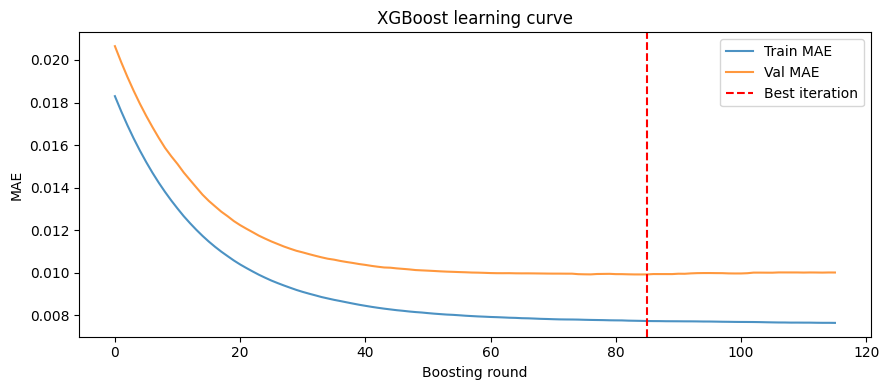

In [30]:
import matplotlib.pyplot as plt

# Plot XGBoost learning curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(evals_result['train']['mae'], label='Train MAE', alpha=0.8)
ax.plot(evals_result['val']['mae'],   label='Val MAE',   alpha=0.8)
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--', label='Best iteration')
ax.set_xlabel('Boosting round')
ax.set_ylabel('MAE')
ax.set_title('XGBoost learning curve')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'xgb_learning_curve.png'), dpi=120)
plt.show()

---
## Section 5 — Metrics Report + Plots
**Prerequisite: Sections 0-4 complete, or at least Section 2-3. Reload cell handles reconnects.**

In [31]:
import pickle, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_DIR = '/content/drive/MyDrive/space_debris_baselines'

with open(os.path.join(SAVE_DIR, 'processed_splits.pkl'), 'rb') as f:
    d = pickle.load(f)
test_df = d['test_df']
y_test = d['y_test']
FEATURE_COLS = d['FEATURE_COLS']

with open(os.path.join(SAVE_DIR, 'results.pkl'), 'rb') as f:
    results = pickle.load(f)

print('Loaded results for:', [k for k in results.keys()])

Loaded results for: ['Persist (current sigma)', 'Global mean', 'Altitude-band median', 'Per-object median', 'Ridge (val)', 'Ridge', 'Random Forest (val)', 'Random Forest', 'XGBoost (val)', 'XGBoost']


In [32]:
# === Summary table ===
test_models = {k: v for k, v in results.items() if 'val' not in k.lower()}

summary = pd.DataFrame([
    {'Model': name, 'MAE': v['MAE'], 'RMSE': v['RMSE'], 'R²': v['R2']}
    for name, v in test_models.items()
]).sort_values('MAE')

print('=== REGRESSION BASELINE RESULTS (test set) ===')
print(summary.to_string(index=False, float_format='{:.4f}'.format))

summary.to_csv(os.path.join(SAVE_DIR, 'results_summary.csv'), index=False)
print('\nSaved to results_summary.csv')

=== REGRESSION BASELINE RESULTS (test set) ===
                  Model    MAE   RMSE      R²
          Random Forest 0.0102 0.0365  0.5135
                XGBoost 0.0104 0.0365  0.5133
Persist (current sigma) 0.0117 0.0309  0.6513
                  Ridge 0.0138 0.0315  0.6364
      Per-object median 0.0162 0.0393  0.4355
            Global mean 0.0213 0.0530 -0.0289
   Altitude-band median 0.0220 0.0540 -0.0655

Saved to results_summary.csv


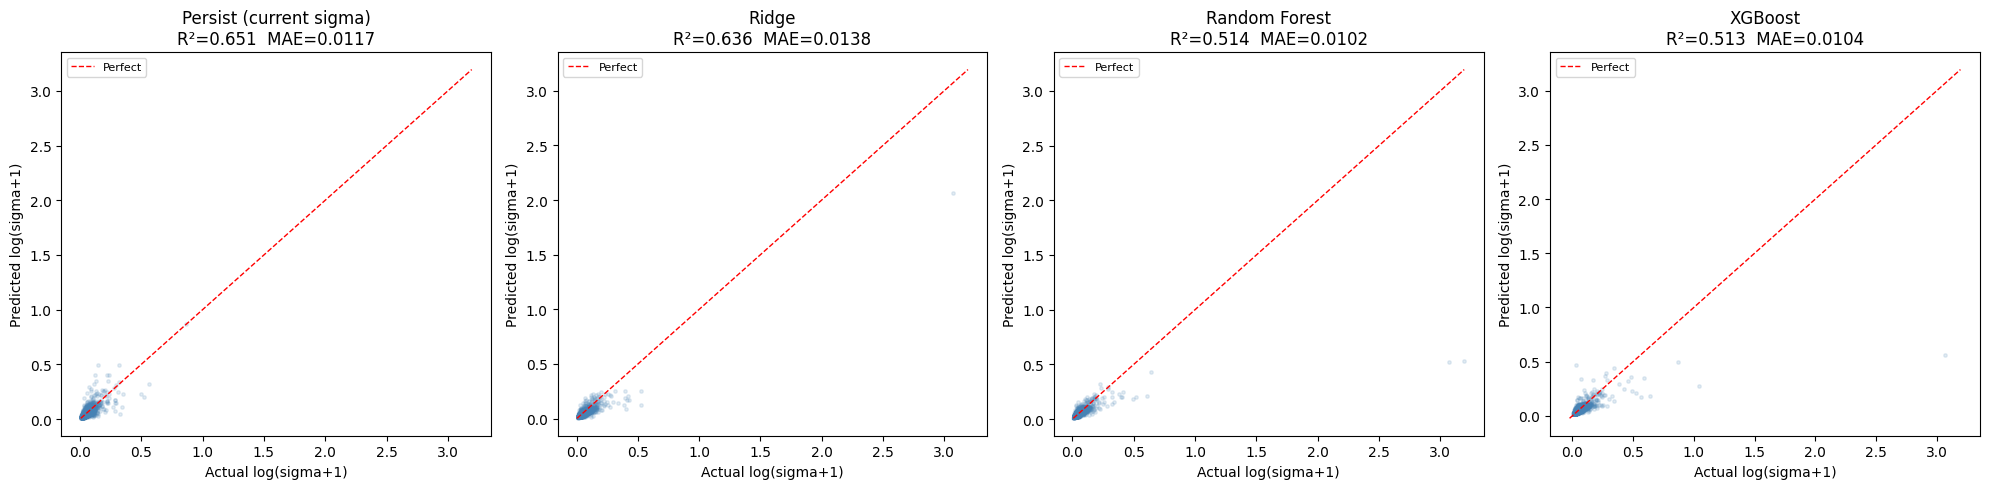

In [33]:
# === Predicted vs Actual plots ===
plot_models = {k: v for k, v in test_models.items() if 'median' not in k.lower() and 'mean' not in k.lower()}

n_plots = len(plot_models)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
if n_plots == 1:
    axes = [axes]

for ax, (name, v) in zip(axes, plot_models.items()):
    y_pred = v['y_pred']
    # Subsample for speed
    idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
    ax.scatter(y_test[idx], y_pred[idx], alpha=0.15, s=6, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')
    ax.set_xlabel('Actual log(sigma+1)')
    ax.set_ylabel('Predicted log(sigma+1)')
    ax.set_title(f'{name}\nR²={v["R2"]:.3f}  MAE={v["MAE"]:.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pred_vs_actual.png'), dpi=130)
plt.show()

Mean absolute error by altitude band:
altitude_band              VLEO  LEO_low  LEO_mid  LEO_high    MEO+
model                                                              
Altitude-band median     0.0087   0.0226   0.0170    0.0255  0.0702
Global mean              0.0130   0.0209   0.0164    0.0248  0.0730
Per-object median        0.0077   0.0191   0.0119    0.0209  0.0455
Persist (current sigma)  0.0109   0.0128   0.0083    0.0147  0.0407
Random Forest            0.0112   0.0108   0.0072    0.0129  0.0380
Ridge                    0.0151   0.0145   0.0109    0.0163  0.0407
XGBoost                  0.0388   0.0110   0.0073    0.0128  0.0379


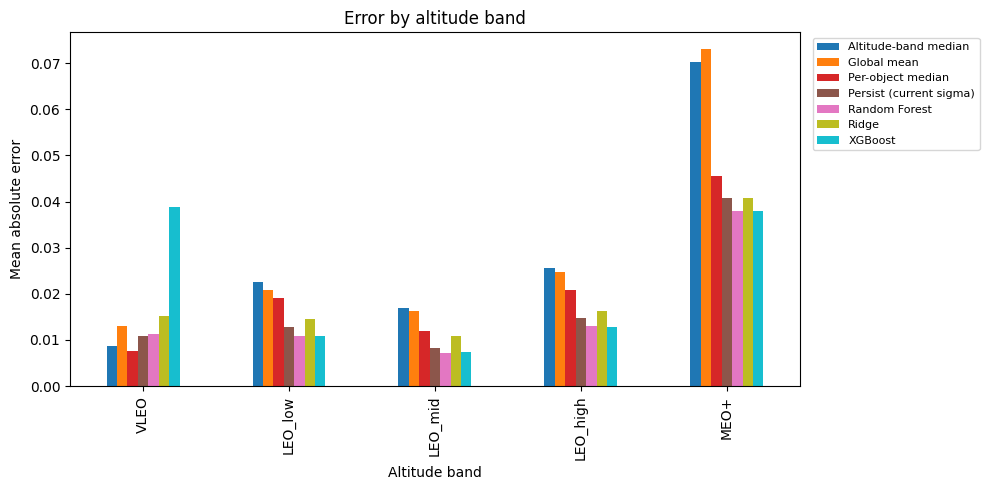

In [34]:
# === Error by altitude band (where does each model fail?) ===
band_results = []

for name, v in test_models.items():
    y_pred = v['y_pred']
    residuals = np.abs(y_pred - y_test)
    tmp = test_df[['altitude_band']].copy()
    tmp['abs_error'] = residuals
    tmp['model'] = name
    band_results.append(tmp)

band_df = pd.concat(band_results, ignore_index=True)
band_pivot = band_df.groupby(['model', 'altitude_band'])['abs_error'].mean().unstack()

print('Mean absolute error by altitude band:')
print(band_pivot.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
band_pivot.T.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_xlabel('Altitude band')
ax.set_ylabel('Mean absolute error')
ax.set_title('Error by altitude band')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'error_by_altitude_band.png'), dpi=130)
plt.show()

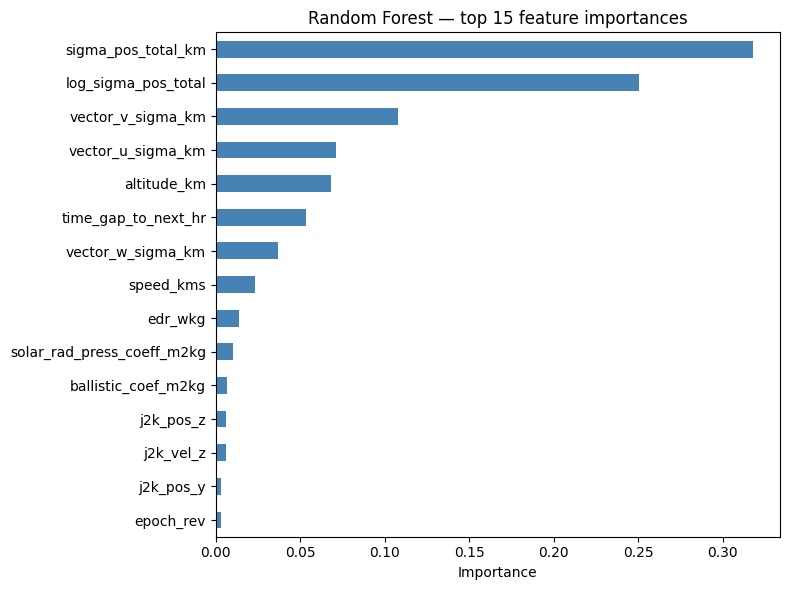

In [35]:
# === Feature importance plot (RF if available) ===
rf_path = os.path.join(SAVE_DIR, 'rf_model.pkl')
if os.path.exists(rf_path):
    from sklearn.ensemble import RandomForestRegressor
    with open(rf_path, 'rb') as f:
        rf = pickle.load(f)

    imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Random Forest — top 15 feature importances')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'rf_feature_importance.png'), dpi=130)
    plt.show()
else:
    print('RF model not found — run Section 3 first.')

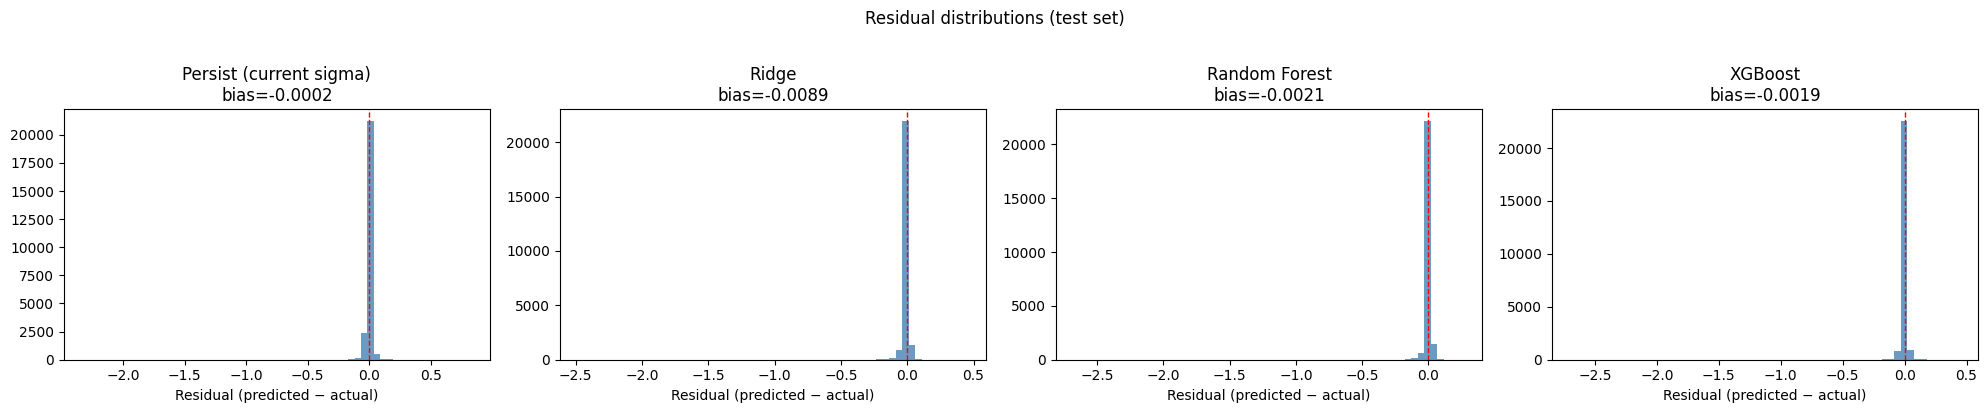

In [36]:
# === Residual distribution (are errors normally distributed?) ===
fig, axes = plt.subplots(1, len(plot_models), figsize=(5 * len(plot_models), 4))
if len(plot_models) == 1:
    axes = [axes]

for ax, (name, v) in zip(axes, plot_models.items()):
    residuals = v['y_pred'] - y_test
    ax.hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Residual (predicted − actual)')
    ax.set_title(f'{name}\nbias={residuals.mean():.4f}')

plt.suptitle('Residual distributions (test set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'residual_distributions.png'), dpi=130)
plt.show()

In [37]:
# === Final summary for the team report ===
print('=' * 60)
print('FINAL SUMMARY FOR TEAM REPORT')
print('=' * 60)
print(f'Target: {d["PRIMARY_TARGET"]}')
print(f'Test set size: {len(y_test):,} rows')
print()
print(summary.to_string(index=False, float_format='{:.4f}'.format))
print()

# Best model
best_name = summary.iloc[0]['Model']
best_r2   = summary.iloc[0]['R²']
persist_r2 = results.get('Persist (current sigma)', {}).get('R2', None)

if persist_r2 is not None:
    improvement = best_r2 - persist_r2
    print(f'Best model: {best_name}')
    print(f'R² improvement over persist baseline: +{improvement:.4f}')

print()
print('All outputs saved to:', SAVE_DIR)
print('Files:')
for f in os.listdir(SAVE_DIR):
    print(f'  {f}')

FINAL SUMMARY FOR TEAM REPORT
Target: target_log_sigma
Test set size: 24,539 rows

                  Model    MAE   RMSE      R²
          Random Forest 0.0102 0.0365  0.5135
                XGBoost 0.0104 0.0365  0.5133
Persist (current sigma) 0.0117 0.0309  0.6513
                  Ridge 0.0138 0.0315  0.6364
      Per-object median 0.0162 0.0393  0.4355
            Global mean 0.0213 0.0530 -0.0289
   Altitude-band median 0.0220 0.0540 -0.0655

Best model: Random Forest
R² improvement over persist baseline: +-0.1378

All outputs saved to: /content/drive/MyDrive/space_debris_baselines
Files:
  processed_splits.pkl
  results.pkl
  ridge_model.pkl
  rf_model.pkl
  xgb_model.json
  xgb_learning_curve.png
  results_summary.csv
  pred_vs_actual.png
  error_by_altitude_band.png
  rf_feature_importance.png
  residual_distributions.png
